# Teacher Guide — Prac 06: Clustering

This notebook is a **teacher-facing walkthrough** for the supplied clustering practical. It follows the structure and completed code in the provided student and answer notebooks, but adds detailed explanations, teaching prompts, expected interpretations, and runnable outputs.

> **Teaching goal:** Students should understand *what the code is doing and why*, rather than only filling in blanks.

## Learning outcomes
By the end of the practical, students should be able to:

- explain the difference between **supervised classification** and **unsupervised clustering**;
- generate and visualise a synthetic 3-dimensional dataset;
- apply **Agglomerative Clustering**, **Gaussian Mixture**, **KMeans**, and **DBSCAN**;
- interpret a **dendrogram**;
- calculate and interpret **SSQ (sum of squared errors)**;
- use **Davies–Bouldin** and **Silhouette** scores;
- use validation metrics to choose a sensible value of **k** for KMeans.

### Important teacher note
Some numerical results from KMeans and Gaussian Mixture can vary slightly between runs or scikit-learn versions because of model initialisation. The interpretation should remain the same.

# Q1 — Exploring clustering methods

The practical starts with simulated data for which we know the original class labels. This is useful for teaching because we can visually compare the **true classes** with the **clusters discovered without using those labels**.

## Start with this conceptual question
Ask students:

> **If clustering is unsupervised, why do we have `y` labels at all?**

Expected idea: `y` is only available because this is a simulated teaching dataset. The clustering algorithms will be fitted using **`X` only**. We keep `y` so that we can later compare the discovered clusters with the known structure.

## 0. Standard imports

Explain that these imports provide:

- `matplotlib.pyplot` — plotting;
- `numpy` — arrays and numerical operations;
- `pandas` — tables/DataFrames;
- `seaborn` — convenient statistical plots;
- `sklearn` — machine-learning algorithms and metrics.

In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import sklearn
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Generate the data

The supplied practical uses `sklearn.datasets.make_classification` to create a dataset with:

- **1000 observations**;
- **3 input features**;
- **3 known classes**;
- one compact cluster per class;
- relatively strong class separation.

### Parameter walkthrough

`n_samples=1000`  
Creates 1000 rows/observations.

`n_features=3`  
Each row contains three feature values. We can therefore plot the data in 3D.

`n_informative=3`  
All three features contribute useful information to separating the classes.

`n_redundant=0`  
No feature is generated simply as a redundant combination of other features.

`n_clusters_per_class=1`  
Each true class forms one main cluster.

`n_classes=3`  
There are three true classes.

`class_sep=3`  
Controls how separated the classes are. Here the classes are made reasonably distinct.

`random_state=123`  
Makes the generated dataset reproducible.

### Teaching prompt
Before running the next cell, ask:

> **What shape should `X` have?**

Expected answer: `(1000, 3)`.

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000,
                           n_features=3,
                           n_informative=3,
                           n_redundant=0,
                           n_clusters_per_class=1,
                           n_classes=3,
                           class_sep=3,
                           # flip_y is left at its default, so a few labels may appear unusual
                           random_state=123)

## Inspect `X` and `y`

`X` contains the **feature values**. Each row is one observation and each column is one feature.

`y` contains the **known class label** for each row.

A useful distinction to put on the board is:

| Variable | Meaning |
|---|---|
| `X` | input feature values used by clustering |
| `y` | true labels supplied only because this is simulated data |
| `yhat` | cluster labels discovered by an algorithm |

In [3]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 rows of X:")
print(X[:5])
print("First 10 class labels:", y[:10])
print("Unique true classes:", np.unique(y))

X shape: (1000, 3)
y shape: (1000,)
First 5 rows of X:
[[-3.81751249 -2.0802058  -3.48003039]
 [-1.59232213 -2.2662944   2.87441365]
 [-2.21970032 -4.8090641  -1.49697326]
 [-2.9336968  -3.10775071 -2.932154  ]
 [-3.29302515  2.61143644  2.41094908]]
First 10 class labels: [0 1 0 0 2 2 2 0 2 1]
Unique true classes: [0 1 2]


# 2. Visualise the data in 3D

Because the dataset has exactly three features, each observation can be represented as a point:

\[
(x, y, z)
\]

The helper function below loops through each class value and plots the corresponding rows.

## Walk through the key lines

### `for class_value in pd.unique(y)`
Loops through the unique class labels.

### `row_ix = np.where(y == class_value)`
Creates a Boolean comparison and finds the row indices where the label equals the current class.

For a tiny example:

```python
y = np.array([0, 1, 0, 2, 1])
y == 0
```

would conceptually give:

```text
[True, False, True, False, False]
```

and `np.where(...)` returns the positions of the `True` values.

### `X[row_ix, 0]`, `X[row_ix, 1]`, `X[row_ix, 2]`
Select the first, second, and third feature for those rows. These become the 3D coordinates.

In [4]:
def plot3d(X, y):
    fig, ax = plt.subplots(1, 1, subplot_kw={'projection':'3d'})

    # create scatter plot for samples from each class/cluster label
    for class_value in pd.unique(y):
        row_ix = np.where(y == class_value)
        ax.scatter(X[row_ix, 0], X[row_ix, 1], X[row_ix, 2])

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    plt.show()

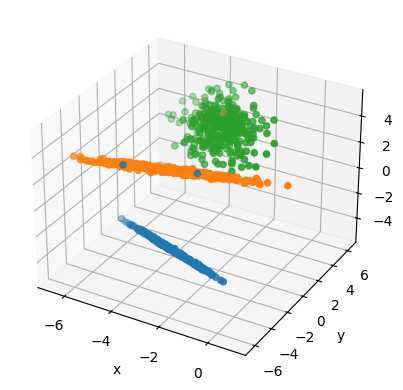

In [5]:
plot3d(X, y)

### Expected interpretation
Students should see roughly **three clouds of points**.

There may be a small number of points that appear to sit nearer another class. The source notebook explicitly notes that some points appear to be in the “wrong” cluster visually. This is useful later because a clustering algorithm may group those points differently from their supplied class label.

### Ask students
> **If we removed the colours and the `y` labels, how could a computer try to recover the three groups?**

That question leads naturally into clustering.

## Optional 2D pairwise visualisation

The student notebook also creates a pairplot. This shows every pair of features against each other and colours observations using the known class label.

This is useful if students find the 3D plot difficult to rotate or interpret.

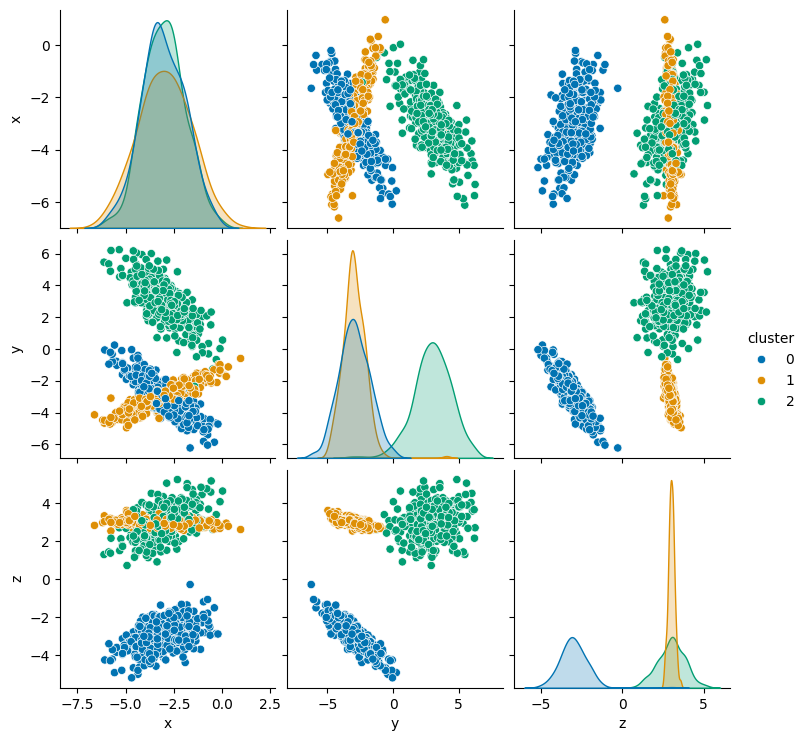

In [6]:
df1 = pd.DataFrame(X, columns=['x','y','z'])
df2 = pd.DataFrame(y, columns=['cluster'])
df = df1.join(df2)
sns.pairplot(df, hue='cluster', palette=sns.color_palette('colorblind', 3))
plt.show()

# 3. Agglomerative Clustering

The practical next uses **bottom-up Agglomerative Clustering**.

## Explain the algorithm without code first

Agglomerative clustering starts with each observation as its own tiny cluster and repeatedly merges the nearest clusters.

A simple board sketch:

```text
A     B          C     D
 \   /            \   /
  A-B              C-D
       \          /
          A-B-C-D
```

So the process is:

1. start with many small clusters;
2. find two clusters that are closest according to the linkage rule;
3. merge them;
4. repeat;
5. build a hierarchy of cluster merges.

This hierarchy can be visualised using a **dendrogram**.

In [7]:
from sklearn.cluster import AgglomerativeClustering

## Build the full hierarchy

The source answer uses:

```python
AgglomerativeClustering(distance_threshold=0, n_clusters=None)
```

This tells scikit-learn not to stop at a preset number of clusters. Instead, it builds the complete merge hierarchy so that we can inspect it with a dendrogram.

In [8]:
model_ac_full = AgglomerativeClustering(distance_threshold=0,
                                        n_clusters=None)

## Dendrogram helper

The following helper function is from the supplied answer notebook. It converts the fitted scikit-learn hierarchy into the linkage structure expected by SciPy's `dendrogram` function.

You do **not** need to make students memorise this helper. Focus on the interpretation of the resulting dendrogram.

In [9]:
from scipy.cluster.hierarchy import dendrogram

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([
        model.children_,
        model.distances_,
        counts
    ]).astype(float)

    dendrogram(linkage_matrix, **kwargs)

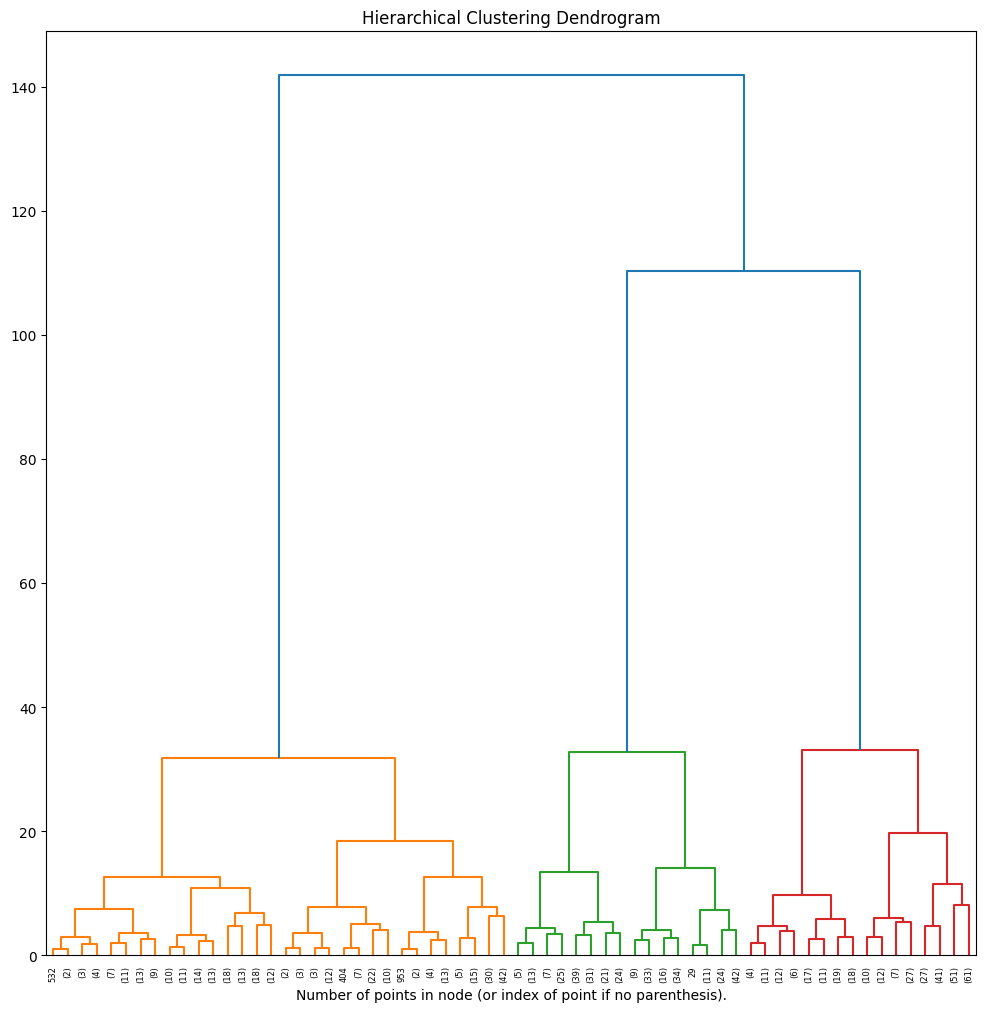

In [10]:
plt.figure(figsize=(12, 12))
plt.title('Hierarchical Clustering Dendrogram')

# Fit only on X — not on y
model_ac_full.fit(X)

# Show the upper levels of the hierarchy
plot_dendrogram(model_ac_full, truncate_mode='level', p=5)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

## How to teach the dendrogram

A dendrogram records **which clusters merged and at what distance**.

- Lower merges indicate clusters that are relatively similar/close.
- Large vertical jumps indicate that substantially different groups are being forced together.

### Choosing the number of clusters
A common visual method is to look for a large vertical separation between major merges and imagine drawing a horizontal line through that gap. Count how many major branches the line crosses.

For the supplied dataset, the intended interpretation is approximately:

> **3 natural clusters**

This agrees with the fact that the simulated dataset was created with three classes.

## Refit Agglomerative Clustering with 3 clusters

Now that we have chosen the number of clusters, we create a new model that stops at three clusters.

In [11]:
model_ac = AgglomerativeClustering(n_clusters=3)

## Student blank: `yhat = ?`

The completed answer is:

```python
yhat = model_ac.fit_predict(X)
```

### Explain `fit_predict`
It does two steps in one call:

1. **fit** the clustering model to `X`;
2. **predict/return** the cluster assignment for each row.

The result `yhat` has one cluster label per observation.

### Very important teaching point
The numeric labels are arbitrary. For example, the true classes may be numbered `0, 1, 2` while the clustering algorithm may call the same groups `2, 0, 1`.

So do **not** judge clustering quality by checking whether the numbers in `y` exactly equal the numbers in `yhat`.

Unique Agglomerative cluster labels: [0 1 2]


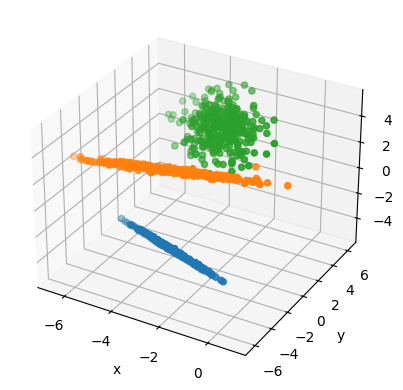

In [12]:
yhat = model_ac.fit_predict(X)
print("Unique Agglomerative cluster labels:", np.unique(yhat))
plot3d(X, yhat)

### Expected interpretation
The plot should again show three clear groups. The source notebook notes that some of the visually unusual points may be assigned by the clustering algorithm to the spatially nearby group rather than to their original simulated label.

That is not automatically an error: the clustering algorithm does not know `y`.

# 4. Sum of Squared Errors (SSQ)

The next task measures how compact the discovered clusters are.

For each cluster:

1. calculate its **centroid** (mean position);
2. calculate each point's difference from that centroid;
3. square the differences;
4. add them together.

Conceptually:

\[
SSQ = \sum_{clusters}\sum_{points\ in\ cluster}\sum_{features}(x - centroid)^2
\]

### Interpretation
- **lower SSQ** generally means points are more tightly grouped around their cluster centres;
- however, SSQ naturally falls as the number of clusters increases, so it should not be used alone to keep increasing `k` indefinitely.

## Walk through `calc_ssq`

### `clusters = np.unique(yhat)`
Find all cluster labels.

### `cluster = X[np.where(yhat == c)]`
Select only the observations assigned to cluster `c`.

### `centroid = np.mean(cluster, axis=0)`
Calculate the mean of each feature column.

For a 3-feature dataset, the centroid is itself a 3-value point:

```text
(mean feature 1, mean feature 2, mean feature 3)
```

### `distances = cluster - centroid`
Subtract the centroid from every point in that cluster.

### `distances**2`
Square each difference so positive and negative differences do not cancel.

### `np.sum(...)`
Add the squared differences.

In [13]:
def calc_ssq(X, yhat):
    clusters = np.unique(yhat)
    ssq = 0

    for c in clusters:
        cluster = X[np.where(yhat == c)]
        centroid = np.mean(cluster, axis=0)
        distances = cluster - centroid
        ssq += np.sum(distances**2)

    return ssq

In [14]:
yhat = model_ac.fit_predict(X)
ac_ssq = calc_ssq(X, yhat)
print("Agglomerative SSQ:", ac_ssq)

Agglomerative SSQ: 3130.9629826894597


### Expected result from the supplied answer notebook
Approximately:

```text
3130.96
```

A small difference across environments is not important. The important point is how this score compares with the other clustering methods on the same data.

# 5. Compare more clustering methods

The practical now compares:

- **Gaussian Mixture**;
- **KMeans**;
- **DBSCAN**;
- the Agglomerative result already calculated.

Each method has a different modelling idea, so this is a useful place to stress that there is no universally best clustering algorithm for every dataset.

In [15]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.mixture import GaussianMixture

## 5.1 Gaussian Mixture

A Gaussian Mixture Model treats the dataset as if it were generated from a mixture of several Gaussian probability distributions.

The parameter is called `n_components` rather than `n_clusters` because the model describes **probability-distribution components**.

The supplied answer uses three components:

Gaussian Mixture SSQ: 3139.679294134914


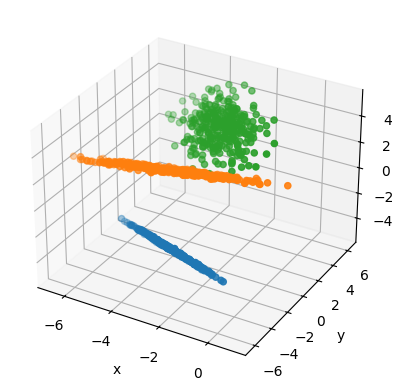

In [16]:
model_gm = GaussianMixture(n_components=3)
yhat = model_gm.fit_predict(X)
gm_ssq = calc_ssq(X, yhat)
print("Gaussian Mixture SSQ:", gm_ssq)
plot3d(X, yhat)

### Expected source result
The answer notebook reports an SSQ of approximately **3139.68**.

Gaussian Mixture initialisation can cause minor differences between runs.

## 5.2 KMeans

KMeans can be taught as an iterative process:

1. choose `k` centroids;
2. assign each observation to its nearest centroid;
3. recompute each centroid from its assigned points;
4. repeat assignment and recomputation until the solution stabilises.

KMeans is closely connected to SSQ because it seeks clusters that minimise within-cluster squared distances.

KMeans SSQ: 3110.6705580544476


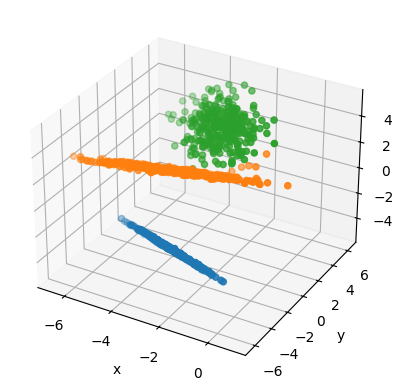

In [17]:
model_km = KMeans(n_clusters=3)
yhat = model_km.fit_predict(X)
km_ssq_3 = calc_ssq(X, yhat)
print("KMeans SSQ:", km_ssq_3)
plot3d(X, yhat)

### Expected source result
The answer notebook reports an SSQ of approximately **3110.67**.

Among the three-cluster methods here, KMeans has a slightly lower SSQ in the supplied solution.

## 5.3 DBSCAN

DBSCAN is conceptually different from KMeans and Agglomerative clustering.

Rather than asking us to specify a number of clusters, DBSCAN identifies **dense regions** of points.

It can also mark observations as **noise/outliers**.

This is why the supplied answer simply uses:

```python
DBSCAN()
```

with default parameters.

DBSCAN SSQ: 3978.147066486108


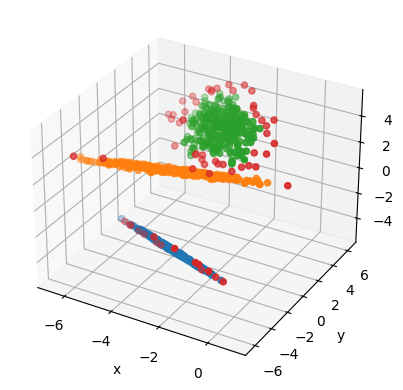

In [18]:
model_db = DBSCAN()
yhat = model_db.fit_predict(X)
db_ssq = calc_ssq(X, yhat)
print("DBSCAN SSQ:", db_ssq)
plot3d(X, yhat)

### Expected source result
The answer notebook reports an SSQ of approximately **3978.15**.

This is worse than the other three methods for this particular dataset under DBSCAN's default settings. That does **not** mean DBSCAN is generally a poor algorithm; it is designed for a different kind of cluster structure and its density parameters matter.

## DBSCAN labels and noise

The source practical asks:

> How many clusters were generated by DBSCAN and how many outlier points were there?

DBSCAN uses the special label:

```text
-1 = noise / outlier
```

Labels `0` and above are actual discovered clusters.

In [19]:
print("Unique DBSCAN labels:", np.unique(model_db.labels_))
labels, counts = np.unique(model_db.labels_, return_counts=True)
print("Label counts:")
for label, count in zip(labels, counts):
    print(f"  {label}: {count}")

Unique DBSCAN labels: [-1  0  1  2]
Label counts:
  -1: 61
  0: 319
  1: 331
  2: 289


### Expected interpretation
The supplied answer notebook shows:

```text
[-1, 0, 1, 2]
```

This means:

- **3 actual clusters**: `0`, `1`, and `2`;
- plus observations labelled `-1`, which are noise/outliers.

Do **not** tell students that `-1` creates a fourth DBSCAN cluster.

# Q2 — Cluster validation metrics

Now we compare the four clustering methods using three validation measures:

1. **SSQ**;
2. **Davies–Bouldin score**;
3. **Silhouette score**.

A useful summary table for students:

| Metric | Desired direction | Intuition |
|---|---|---|
| SSQ | **lower** | compact around centroids |
| Davies–Bouldin | **lower** | compact clusters that are well separated |
| Silhouette | **higher** | points fit their own cluster better than neighbouring clusters |

## 6. Davies–Bouldin score

You do not need to derive the full formula unless it is part of the lecture material.

A simple explanation is:

> It compares how spread out clusters are internally with how well separated different clusters are.

A good solution has compact clusters that are far from one another.

Therefore:

> **Lower Davies–Bouldin is better.**

The best theoretical value approaches 0.

## 7. Silhouette score

For each observation, the silhouette concept compares:

- how close the observation is to points in **its own cluster**;
- how far it is from points in the **nearest competing cluster**.

The score ranges approximately from **-1 to +1**.

Interpretation:

- close to **1** → strong clustering;
- around **0** → overlapping/borderline clusters;
- below **0** → the point may fit another cluster better.

Therefore:

> **Higher Silhouette is better.**

# 8. Create a matrix of method/metric scores

The source notebook builds a list of models and a list of scoring functions.

```python
methods = [model_ac, model_gm, model_km, model_db]
scorers = [calc_ssq, metrics.davies_bouldin_score, metrics.silhouette_score]
```

Then it uses nested loops:

- outer loop → one clustering method at a time;
- inner loop → one scoring function at a time.

### Explain `enumerate`
`enumerate(methods)` returns both:

- the index `i`;
- the model object `m`.

The same is done for the scorers.

### Explain functions as objects
When `scorer` refers to `metrics.silhouette_score`, then:

```python
scorer(X, yhat)
```

is simply another way of calling:

```python
metrics.silhouette_score(X, yhat)
```

In [20]:
from sklearn import metrics

methods = [model_ac, model_gm, model_km, model_db]
scorers = [calc_ssq, metrics.davies_bouldin_score, metrics.silhouette_score]

scores = np.empty(shape=(3, 4))

for i, m in enumerate(methods):
    yhat = m.fit_predict(X)
    for j, scorer in enumerate(scorers):
        score = scorer(X, yhat)
        scores[j, i] = score

In [21]:
score_df = pd.DataFrame(
    scores,
    columns=['Agglomerative', 'GaussianMixture', 'KMeans', 'DBSCAN'],
    index=['SSQ', 'DaviesBouldin', 'Silhouette']
)
score_df

,Agglomerative,GaussianMixture,KMeans,DBSCAN
SSQ,3130.962983,3139.679294,3110.670558,3978.147066
DaviesBouldin,0.491547,0.491721,0.492232,1.844276
Silhouette,0.652397,0.651803,0.653715,0.592118


## How to interpret the score table

From the supplied answer notebook, the values are approximately:

| Metric | Agglomerative | Gaussian Mixture | KMeans | DBSCAN |
|---|---:|---:|---:|---:|
| SSQ | 3130.96 | 3139.68 | 3110.67 | 3978.15 |
| Davies–Bouldin | 0.492 | 0.492 | 0.492 | 1.844 |
| Silhouette | 0.652 | 0.652 | 0.654 | 0.592 |

### Teacher discussion
For this generated dataset:

- Agglomerative, Gaussian Mixture, and KMeans are all quite similar;
- KMeans is marginally strongest on SSQ and Silhouette in the supplied result;
- DBSCAN with default parameters performs less well according to these metrics.

### Caution about DBSCAN and `-1`
The supplied practical computes these metrics directly using the DBSCAN labels, including `-1`. For the purpose of following the practical, keep that behaviour. Conceptually, remind students that `-1` denotes noise rather than a normal DBSCAN cluster.

# 9. Choosing `k` for KMeans using SSQ

KMeans requires us to choose `k` in advance. The practical therefore tries many candidate values and calculates a validation score for each one.

For SSQ, the source answer tests:

```text
k = 1, 2, 3, ..., 20
```

### Why does SSQ decrease as `k` increases?
More clusters make it easier for each point to be close to a centroid.

In the extreme case where every point had its own cluster, SSQ would approach 0. That would not be a useful summary of the data.

So we look for an **elbow**: a point after which adding more clusters gives much smaller improvements.

In [22]:
km_ssq = []

for k in range(1, 21):
    km = KMeans(n_clusters=k)
    yhat = km.fit_predict(X)
    ssq = calc_ssq(X, yhat)
    km_ssq.append(ssq)

print("First few SSQ values:")
for k, ssq in list(zip(range(1, 21), km_ssq))[:6]:
    print(f"k={k:2d}  SSQ={ssq:.2f}")

First few SSQ values:
k= 1  SSQ=19265.00
k= 2  SSQ=9211.96
k= 3  SSQ=3110.67
k= 4  SSQ=2586.40
k= 5  SSQ=1908.62
k= 6  SSQ=1443.40


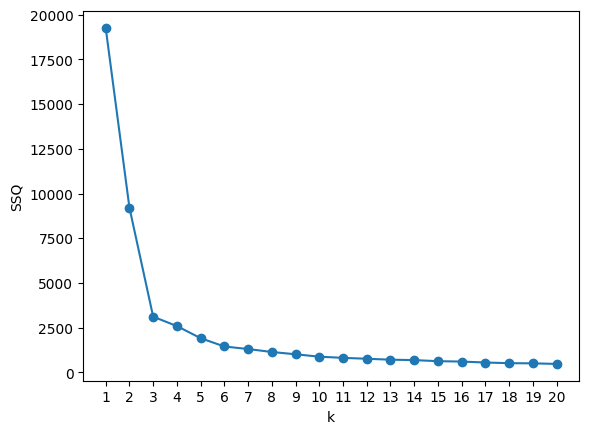

In [23]:
k_vals = range(1, len(km_ssq) + 1)
fig, ax = plt.subplots(1, 1)
ax.plot(k_vals, km_ssq, 'o-')
ax.set_xlabel('k')
ax.set_ylabel('SSQ')
ax.set_xticks(list(k_vals))
plt.show()

## Interpreting the elbow plot

The supplied answer shows a very large reduction from 1 to 2 to 3 clusters, followed by much smaller reductions.

Therefore the intended choice is:

> **k = 3**

This is reassuring because the simulated dataset was created with three known classes.

### Explain `'o-'`
In Matplotlib:

- `o` draws a circular marker at each measured point;
- `-` connects the points with a line.

# 10. Choosing `k` using Davies–Bouldin

For Davies–Bouldin, the source practical starts from `k=2` rather than `k=1`.

Why?

Because the metric evaluates cluster separation relative to other clusters, so a single-cluster solution is not meaningful for this comparison.

Remember:

> **Lower Davies–Bouldin is better.**

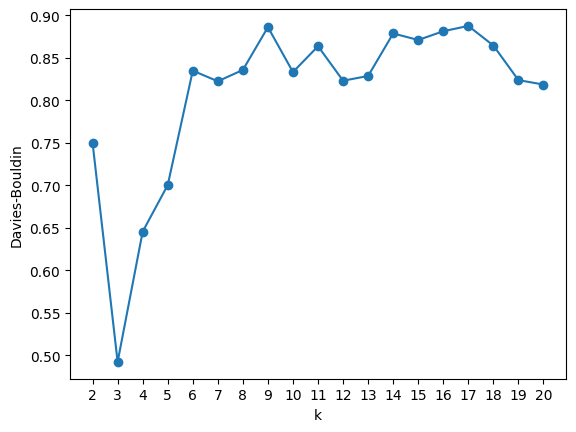

k with minimum Davies-Bouldin score: 3


In [24]:
km_db = []

for k in range(2, 21):
    km = KMeans(n_clusters=k)
    yhat = km.fit_predict(X)
    score = metrics.davies_bouldin_score(X, yhat)
    km_db.append(score)

k_vals_db = range(2, 21)
fig, ax = plt.subplots(1, 1)
ax.plot(k_vals_db, km_db, 'o-')
ax.set_xlabel('k')
ax.set_ylabel('Davies-Bouldin')
ax.set_xticks(list(k_vals_db))
plt.show()

best_db_k = list(k_vals_db)[int(np.argmin(km_db))]
print("k with minimum Davies-Bouldin score:", best_db_k)

### Expected interpretation
The curve should support a small number of well-separated clusters, with the intended practical interpretation centred around **k = 3**.

When teaching, focus on the direction of the metric:

```text
smaller = better
```

# 11. Choosing `k` using Silhouette score

Silhouette also requires at least two clusters.

Remember:

> **Higher Silhouette is better.**

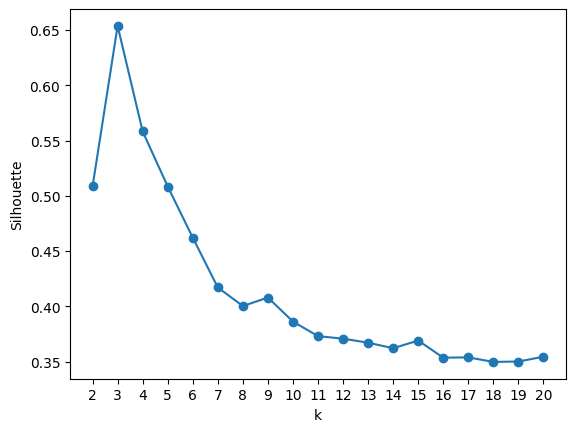

k with maximum Silhouette score: 3


In [25]:
km_s = []

for k in range(2, 21):
    km = KMeans(n_clusters=k)
    yhat = km.fit_predict(X)
    score = metrics.silhouette_score(X, yhat)
    km_s.append(score)

k_vals_s = range(2, 21)
fig, ax = plt.subplots(1, 1)
ax.plot(k_vals_s, km_s, 'o-')
ax.set_xlabel('k')
ax.set_ylabel('Silhouette')
ax.set_xticks(list(k_vals_s))
plt.show()

best_s_k = list(k_vals_s)[int(np.argmax(km_s))]
print("k with maximum Silhouette score:", best_s_k)

### Expected interpretation
The strongest silhouette value should occur around **k = 3**, supporting the same conclusion as the elbow plot.

This gives students an important modelling lesson:

> We are not choosing `k=3` merely because we secretly know there are three true classes. Multiple validation measures independently support approximately the same choice.

# 12. End-of-class recap

Use these questions to check understanding before students leave.

### 1. What is clustering?
Grouping observations according to similarity **without using known target labels**.

### 2. Why did we still have `y` in this practical?
Because the data was simulated. `y` helps us visually inspect the known structure, but clustering methods are fitted using `X`.

### 3. What does Agglomerative Clustering do?
Starts with many small clusters and repeatedly merges nearby clusters.

### 4. What does a dendrogram show?
The hierarchy of merges and the distances at which groups are combined.

### 5. What is `yhat`?
The cluster label assigned to each observation by the fitted clustering method.

### 6. Must the numeric values in `yhat` match the values in `y`?
No. Cluster labels are arbitrary identifiers.

### 7. What does lower SSQ mean?
Points are, overall, closer to their cluster centroids.

### 8. Which direction is better for each metric?

```text
SSQ               → lower is better
Davies–Bouldin    → lower is better
Silhouette        → higher is better
```

### 9. What does DBSCAN label `-1` mean?
Noise/outlier, not an ordinary cluster.

### 10. What value of `k` is supported for this dataset?
Approximately **3**.

# 13. Suggested teaching sequence

If you are presenting this practical live, the clearest order is:

1. explain **classification vs clustering**;
2. generate `X` and `y`;
3. visualise the true groups;
4. explain Agglomerative Clustering with a simple drawing;
5. interpret the dendrogram and choose 3 clusters;
6. introduce `fit_predict()` and `yhat`;
7. explain SSQ with one small cluster and a centroid;
8. run Gaussian Mixture, KMeans, and DBSCAN;
9. explain the special DBSCAN `-1` label;
10. introduce the three validation metrics;
11. compare algorithms in a score table;
12. vary KMeans `k` and use SSQ, Davies–Bouldin, and Silhouette to choose `k`.

This sequence keeps the focus on **why each code cell exists**, not just on syntax.